In [1]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [2]:
from torchvision import transforms

# Update the transform to include padding and normalization
transform_padded = transforms.Compose([
    transforms.Pad(2),  # Pad 28x28 to 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Reload datasets with the new transform
mnist_train_padded = datasets.MNIST(root='./data', train=True, download=True, transform=transform_padded)
mnist_test_padded = datasets.MNIST(root='./data', train=False, download=True, transform=transform_padded)

In [3]:
import torch
import torch.nn as nn

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=0)      # 1×32×32 → 6×28×28
        self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2)        # 6×28×28 → 6×14×14
        
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)     # 6×14×14 → 16×10×10
        self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2)        # 16×10×10 → 16×5×5
        
        # Fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)                        # 400 → 120
        self.fc2 = nn.Linear(120, 84)                                # 120 → 84
        self.fc3 = nn.Linear(84, 10)                                 # 84 → 10 (classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Conv → Pool → Conv → Pool
        x = self.relu(self.conv1(x))
        x = self.avgpool1(x)
        x = self.relu(self.conv2(x))
        x = self.avgpool2(x)
        
        # Flatten for fully connected layers
        x = x.view(x.size(0), -1)
        
        # FC → FC → FC
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

# Instantiate the model
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (avgpool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (avgpool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)


In [4]:
import torch.optim as optim
from torch.utils.data import DataLoader

# Set up training parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Data loaders
batch_size = 64
train_loader = DataLoader(mnist_train_padded, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(mnist_test_padded, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Compute loss
        loss = criterion(outputs, labels)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    train_accuracy = 100 * correct / total
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    train_accuracies.append(train_accuracy)
    print(f'Epoch {epoch+1} - Average Loss: {avg_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')

print('Training completed!')

Epoch [1/5], Step [100/938], Loss: 1.9490
Epoch [1/5], Step [200/938], Loss: 0.3797
Epoch [1/5], Step [300/938], Loss: 0.2336
Epoch [1/5], Step [400/938], Loss: 0.1407
Epoch [1/5], Step [500/938], Loss: 0.1078
Epoch [1/5], Step [600/938], Loss: 0.0259
Epoch [1/5], Step [700/938], Loss: 0.1206
Epoch [1/5], Step [800/938], Loss: 0.1032
Epoch [1/5], Step [900/938], Loss: 0.0584
Epoch 1 - Average Loss: 0.4641, Train Accuracy: 84.70%
Epoch [2/5], Step [100/938], Loss: 0.1007
Epoch [2/5], Step [200/938], Loss: 0.0720
Epoch [2/5], Step [300/938], Loss: 0.0909
Epoch [2/5], Step [400/938], Loss: 0.0147
Epoch [2/5], Step [500/938], Loss: 0.0239
Epoch [2/5], Step [600/938], Loss: 0.0387
Epoch [2/5], Step [700/938], Loss: 0.0461
Epoch [2/5], Step [800/938], Loss: 0.0239
Epoch [2/5], Step [900/938], Loss: 0.0194
Epoch 2 - Average Loss: 0.0776, Train Accuracy: 97.62%
Epoch [3/5], Step [100/938], Loss: 0.0165
Epoch [3/5], Step [200/938], Loss: 0.0031
Epoch [3/5], Step [300/938], Loss: 0.0625
Epoch [3

In [5]:
# Evaluation on test set
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Compute accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}% ({correct}/{total})')


Test Accuracy: 98.97% (9897/10000)


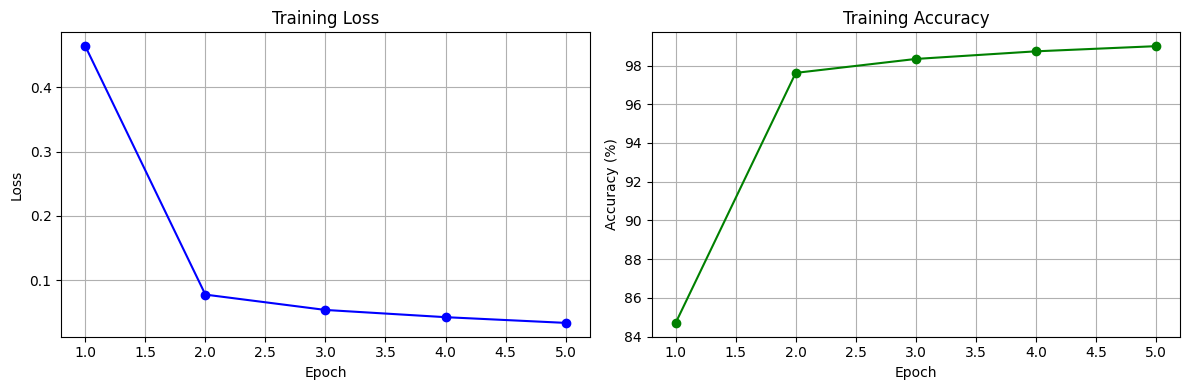


Training Summary:
Final Training Loss: 0.0337
Final Training Accuracy: 99.00%
Test Accuracy: 98.97%


In [6]:
import matplotlib.pyplot as plt

# Plot training loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot training loss
epochs_range = range(1, num_epochs + 1)
ax1.plot(epochs_range, train_losses, 'b-', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Plot training accuracy
ax2.plot(epochs_range, train_accuracies, 'g-', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'\nTraining Summary:')
print(f'Final Training Loss: {train_losses[-1]:.4f}')
print(f'Final Training Accuracy: {train_accuracies[-1]:.2f}%')
print(f'Test Accuracy: {test_accuracy:.2f}%')